## **K-MEANS CLUSTERING**

## PROBLEM STATEMENT: (E-commerce)

* The ecommerce platform offers a wide range of products across categories such as Clothing, Electronics, Books, Toys, Health, Sports, and Home & Kitchen.
*  While the platform collects detailed data on product attributes (price, review scores, review counts) and monthly sales performance, it lacks actionable insights into customer buying patterns,product performance segmentation, and seasonal demand trends.

* The challenge is to analyze this dataset to:

> * Identify clusters of products with similar sales, pricing, and review characteristics.

> * Detect high-performing and underperforming product groups.

> * Understand seasonal sales fluctuations across categories.

> * Provide business recommendations for inventory management, marketing strategies, and promotional planning.

## DATA COLLECTION (E-commerce)

## 📥 Data Collection (E-commerce)

- **Source**: The dataset was collected from an **e-commerce sales platform** (sample dataset inspired by Kaggle-style ecommerce data).  
- **Scope**: It contains **347 products** across multiple categories — Clothing, Electronics, Books, Toys, Health, Sports, and Home & Kitchen.  
- **Attributes Captured**:  
  - **Product Information**: Product ID, Name, Category, Price.  
  - **Customer Feedback**: Review Score (1–5 scale), Review Count.  
  - **Sales Performance**: Monthly sales data for 12 months.  

- **Collection Method**:  
  - Data was aggregated from **transactional records** of product sales.  
  - Customer reviews and ratings were extracted from the platform’s feedback system.  
  - Monthly sales were compiled from order histories to reflect seasonal demand trends.  

- **Purpose of Collection**:  
  - To analyze product performance across categories.  
  - To identify clusters of products with similar characteristics (price, reviews, sales).  
  - To support business decisions in **marketing, inventory management, and customer engagement**.  

## Domain Analysis (E-commerce)

## 🌐 Domain Analysis (E-commerce)

- **Context**: E-commerce platforms sell diverse products across categories like Clothing, Electronics, Books, Toys, Health, Sports, and Home & Kitchen. Success depends on understanding customer demand, reviews, and seasonal trends.  

- **Challenges**:  
  - Product sales vary widely (steady vs. seasonal spikes).  
  - Some items have high review counts but poor ratings.  
  - Inventory mismanagement leads to overstock or shortages.  

- **Analytical Needs**:  
  - Segment products by price, reviews, and sales.  
  - Detect seasonal demand patterns.  
  - Identify top-performing vs. underperforming items.  

- **Role of K-Means**:  
  - Groups products into clusters (premium, value buys, seasonal, low performers).  
  - Provides insights for marketing, promotions, and inventory planning.  

- **Business Impact**:  
  - Better targeting of promotions.  
  - Smarter inventory decisions.  
  - Improved customer satisfaction.  
  - Revenue growth through data-driven strategies.  

## LOADING DATASET

In [7]:
# Load dataset
import pandas as pd
df = pd.read_csv("ecommerce_sales_analysis.csv")

## IMPORTING REQUIED LIBRARIES 

In [8]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Utility
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## BASIC CHECKS

In [9]:
# First few rows
print(df.head())

   product_id product_name        category   price  review_score  \
0           1    Product_1        Clothing  190.40           1.7   
1           2    Product_2  Home & Kitchen  475.60           3.2   
2           3    Product_3            Toys  367.34           4.5   
3           4    Product_4            Toys  301.34           3.9   
4           5    Product_5           Books   82.23           4.2   

   review_count  sales_month_1  sales_month_2  sales_month_3  sales_month_4  \
0           220            479            449             92            784   
1           903             21            989            861            863   
2           163            348            558            567            143   
3           951            725            678             59             15   
4           220            682            451            649            301   

   sales_month_5  sales_month_6  sales_month_7  sales_month_8  sales_month_9  \
0            604            904     

In [10]:
# Shape of dataset
print("Rows:", df.shape[0], "Columns:", df.shape[1])

Rows: 1000 Columns: 18


In [11]:
# Check column types and non-null counts
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      1000 non-null   int64  
 1   product_name    1000 non-null   object 
 2   category        1000 non-null   object 
 3   price           1000 non-null   float64
 4   review_score    1000 non-null   float64
 5   review_count    1000 non-null   int64  
 6   sales_month_1   1000 non-null   int64  
 7   sales_month_2   1000 non-null   int64  
 8   sales_month_3   1000 non-null   int64  
 9   sales_month_4   1000 non-null   int64  
 10  sales_month_5   1000 non-null   int64  
 11  sales_month_6   1000 non-null   int64  
 12  sales_month_7   1000 non-null   int64  
 13  sales_month_8   1000 non-null   int64  
 14  sales_month_9   1000 non-null   int64  
 15  sales_month_10  1000 non-null   int64  
 16  sales_month_11  1000 non-null   int64  
 17  sales_month_12  1000 non-null   in

In [12]:
# Summary statistics
print(df.describe())

        product_id        price  review_score  review_count  sales_month_1  \
count  1000.000000  1000.000000   1000.000000   1000.000000    1000.000000   
mean    500.500000   247.677130      3.027600    526.506000     498.306000   
std     288.819436   144.607983      1.171243    282.269932     289.941478   
min       1.000000     7.290000      1.000000      1.000000       0.000000   
25%     250.750000   121.810000      2.000000    283.750000     245.500000   
50%     500.500000   250.920000      3.100000    543.000000     507.500000   
75%     750.250000   373.435000      4.000000    772.000000     740.750000   
max    1000.000000   499.860000      5.000000    999.000000    1000.000000   

       sales_month_2  sales_month_3  sales_month_4  sales_month_5  \
count    1000.000000    1000.000000    1000.000000    1000.000000   
mean      507.661000     506.739000     503.823000     487.194000   
std       285.992689     294.010873     286.645567     287.844324   
min         2.000000 

In [13]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [14]:
# Count missing values per column
print(df.isnull().sum())

product_id        0
product_name      0
category          0
price             0
review_score      0
review_count      0
sales_month_1     0
sales_month_2     0
sales_month_3     0
sales_month_4     0
sales_month_5     0
sales_month_6     0
sales_month_7     0
sales_month_8     0
sales_month_9     0
sales_month_10    0
sales_month_11    0
sales_month_12    0
dtype: int64


In [15]:
# Unique categories
print(df['category'].unique())

['Clothing' 'Home & Kitchen' 'Toys' 'Books' 'Electronics' 'Health'
 'Sports']


In [16]:
# Count of products per category
print(df['category'].value_counts())

category
Books             154
Sports            153
Toys              151
Clothing          140
Health            139
Electronics       138
Home & Kitchen    125
Name: count, dtype: int64


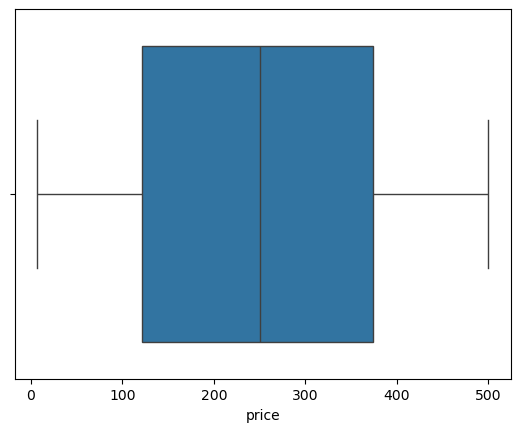

In [18]:
# Price distribution
sns.boxplot(x=df['price'])
plt.show()

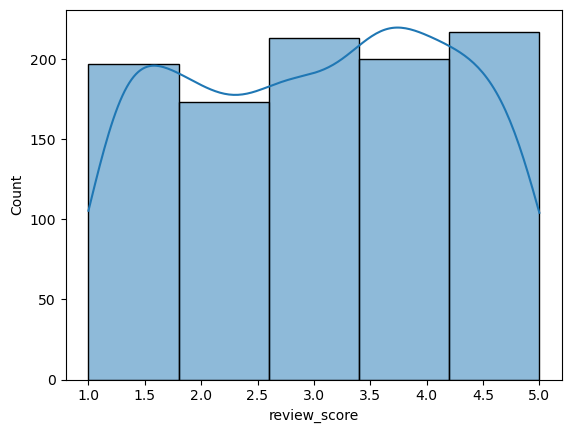

In [19]:
# Review score distribution
sns.histplot(df['review_score'], bins=5, kde=True)
plt.show()

## 🎯 Why These Checks Matter
- **Shape & Info** → confirms dataset size and structure.  
- **Missing Values** → ensures clean input for clustering.  
- **Duplicates** → prevents bias in analysis.  
- **Unique Values** → helps understand categorical spread.  
- **Outliers** → important for scaling before K-means.  

## Exploratory Data Analysis (EDA)

In [21]:
# Basic info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      1000 non-null   int64  
 1   product_name    1000 non-null   object 
 2   category        1000 non-null   object 
 3   price           1000 non-null   float64
 4   review_score    1000 non-null   float64
 5   review_count    1000 non-null   int64  
 6   sales_month_1   1000 non-null   int64  
 7   sales_month_2   1000 non-null   int64  
 8   sales_month_3   1000 non-null   int64  
 9   sales_month_4   1000 non-null   int64  
 10  sales_month_5   1000 non-null   int64  
 11  sales_month_6   1000 non-null   int64  
 12  sales_month_7   1000 non-null   int64  
 13  sales_month_8   1000 non-null   int64  
 14  sales_month_9   1000 non-null   int64  
 15  sales_month_10  1000 non-null   int64  
 16  sales_month_11  1000 non-null   int64  
 17  sales_month_12  1000 non-null   in

,product_id,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,247.677130,3.027600,526.506000,498.306000,507.661000,506.739000,503.823000,487.194000,491.653000,507.011000,504.569000,491.934000,514.798000,505.83800,500.386000
std,288.819436,144.607983,1.171243,282.269932,289.941478,285.992689,294.010873,286.645567,287.844324,289.234018,291.047287,289.945691,287.514731,288.710119,288.82451,278.509459
min,1.000000,7.290000,1.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,1.000000,0.00000,4.000000
25%,250.750000,121.810000,2.000000,283.750000,245.500000,262.500000,243.750000,261.500000,221.000000,236.000000,254.000000,240.500000,247.250000,267.000000,251.25000,259.000000
50%,500.500000,250.920000,3.100000,543.000000,507.500000,508.000000,493.000000,501.500000,497.000000,479.500000,522.500000,499.500000,495.500000,532.000000,502.00000,500.500000
75%,750.250000,373.435000,4.000000,772.000000,740.750000,756.250000,777.250000,749.500000,727.000000,740.500000,757.250000,762.250000,735.250000,770.250000,761.00000,730.000000
max,1000.000000,499.860000,5.000000,999.000000,1000.000000,1000.000000,999.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000


In [23]:
# Category distribution
df['category'].value_counts()

category
Books             154
Sports            153
Toys              151
Clothing          140
Health            139
Electronics       138
Home & Kitchen    125
Name: count, dtype: int64

- Check product counts per category.  
- Identify ranges for price, review scores, and sales.

### 2. **Univariate Analysis**

<Axes: xlabel='price', ylabel='Count'>

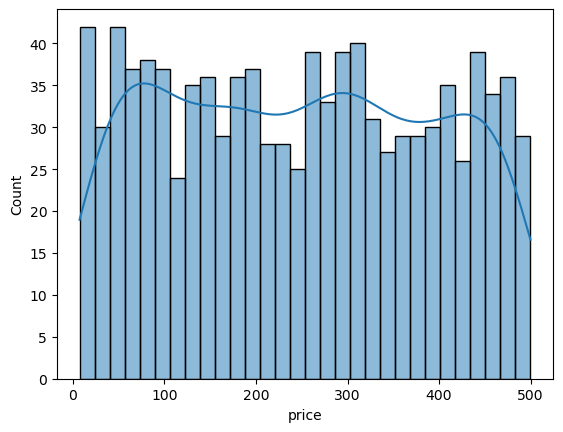

In [31]:
##- **Price Distribution**  
sns.histplot(df['price'], bins=30, kde=True)

<Axes: xlabel='review_score', ylabel='count'>

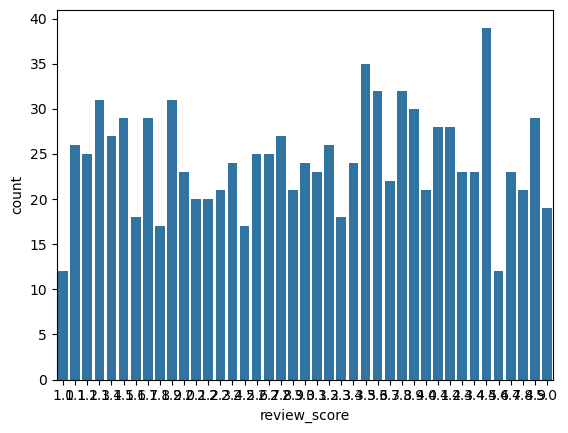

In [29]:
##- **Review Score Distribution**  
sns.countplot(x='review_score', data=df)

<Axes: xlabel='avg_sales', ylabel='Count'>

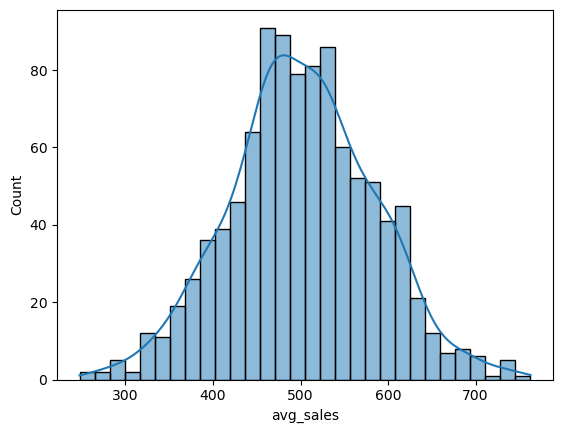

In [30]:
##- **Sales Distribution (Average across months)**  
df['avg_sales'] = df[[f'sales_month_{i}' for i in range(1,13)]].mean(axis=1)
sns.histplot(df['avg_sales'], bins=30, kde=True)

### 3. **Category-Level Insights**

In [ ]:
# Average sales per category
df.groupby('category')['avg_sales'].mean().sort_values(ascending=False)

In [ ]:
# Average review score per category
df.groupby('category')['review_score'].mean().sort_values(ascending=False)
```

- Compare categories by sales and ratings.  
- Spot which categories dominate in performance.

### 4. **Bivariate Analysis**

<Axes: xlabel='price', ylabel='avg_sales'>

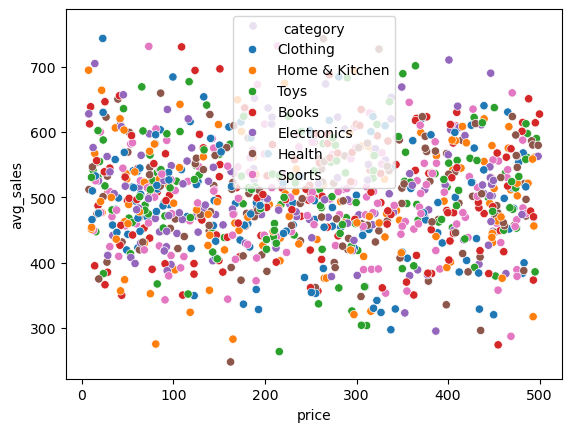

In [34]:
###- **Price vs. Average Sales**
sns.scatterplot(x='price', y='avg_sales', hue='category', data=df)

<Axes: xlabel='review_score', ylabel='avg_sales'>

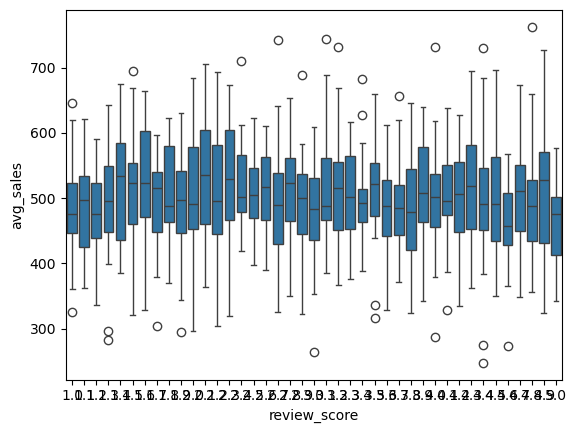

In [33]:
###- **Review Score vs. Average Sales**
sns.boxplot(x='review_score', y='avg_sales', data=df)

### 5. **Seasonal Trends**

<Axes: >

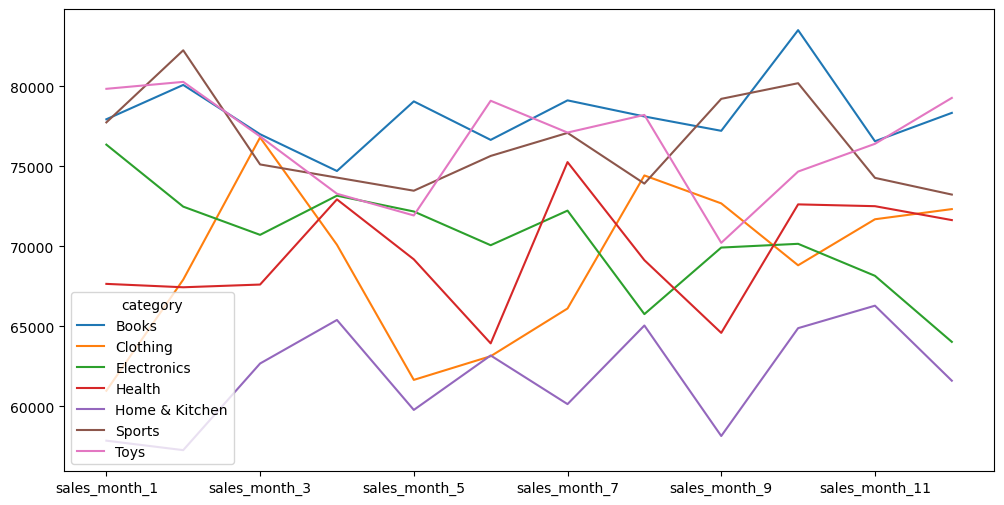

In [35]:
# Monthly sales trend across categories
monthly_sales = df.groupby('category')[[f'sales_month_{i}' for i in range(1,13)]].sum().T
monthly_sales.plot(figsize=(12,6))

- Identify seasonal peaks (e.g., Toys & Sports around festive months).  
- Books show steadier demand compared to Electronics.  


### 6. **Correlation Analysis**

<Axes: >

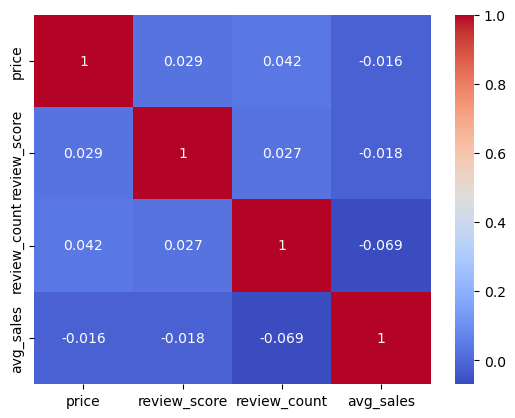

In [38]:
# Correlation heatmap
corr = df[['price','review_score','review_count','avg_sales']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

- Reveals relationships between price, reviews, and sales. 

- **High-priced Electronics** → volatile sales, not always high reviews.  
- **Books & Clothing** → steady demand, often good reviews.  
- **Toys & Sports** → seasonal spikes.  
- **Health products** → wide variation, some top performers with 5-star reviews.  


## FEATURE SELECTION

## 🎯 Feature Selection:

To apply K-means clustering effectively, we need to select **numerical features** that represent product performance and customer perception. From your dataset, the most relevant features are:

### 1. **Price**
- Indicates product positioning (budget vs. premium).  
- Helps separate clusters by affordability.

### 2. **Review Score**
- Reflects customer satisfaction (1–5 scale).  
- Important for identifying high-quality vs. low-quality products.

### 3. **Review Count**
- Shows popularity and engagement.  
- High counts with low scores may indicate dissatisfaction.


### 4. **Average Sales**

In [41]:
df['avg_sales'] = df[[f'sales_month_{i}' for i in range(1,13)]].mean(axis=1)
df

,product_id,product_name,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12,avg_sales
0,1,Product_1,Clothing,190.40,1.7,220,479,449,92,784,604,904,446,603,807,252,695,306,535.083333
1,2,Product_2,Home & Kitchen,475.60,3.2,903,21,989,861,863,524,128,610,436,176,294,772,353,502.250000
2,3,Product_3,Toys,367.34,4.5,163,348,558,567,143,771,409,290,828,340,667,267,392,465.000000
3,4,Product_4,Toys,301.34,3.9,951,725,678,59,15,937,421,670,933,56,157,168,203,418.500000
4,5,Product_5,Books,82.23,4.2,220,682,451,649,301,620,293,411,258,854,548,770,257,507.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Product_996,Home & Kitchen,50.33,3.6,494,488,359,137,787,678,970,282,155,57,575,634,393,459.583333
996,997,Product_997,Home & Kitchen,459.07,4.8,701,18,906,129,78,19,110,403,683,104,858,729,474,375.916667
997,998,Product_998,Sports,72.73,1.3,287,725,109,193,657,215,337,664,476,265,344,888,654,460.583333
998,999,Product_999,Sports,475.37,1.2,720,196,191,315,622,854,122,65,938,521,268,60,394,378.833333


- Captures overall demand across 12 months.  
- Smooths seasonal fluctuations into a single metric.

## 🛠️ Optional Features (if needed)
- **Sales Variance** → measures seasonality (products with spikes vs. steady demand).  
- **Category Encoding** → one-hot encode categories if you want clustering across product types.  



In [43]:
df['sales_variance'] = df[[f'sales_month_{i}' for i in range(1,13)]].var(axis=1)
df

,product_id,product_name,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12,avg_sales,sales_variance
0,1,Product_1,Clothing,190.40,1.7,220,479,449,92,784,604,904,446,603,807,252,695,306,535.083333,59487.537879
1,2,Product_2,Home & Kitchen,475.60,3.2,903,21,989,861,863,524,128,610,436,176,294,772,353,502.250000,102613.840909
2,3,Product_3,Toys,367.34,4.5,163,348,558,567,143,771,409,290,828,340,667,267,392,465.000000,45141.272727
3,4,Product_4,Toys,301.34,3.9,951,725,678,59,15,937,421,670,933,56,157,168,203,418.500000,123556.818182
4,5,Product_5,Books,82.23,4.2,220,682,451,649,301,620,293,411,258,854,548,770,257,507.833333,43626.696970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Product_996,Home & Kitchen,50.33,3.6,494,488,359,137,787,678,970,282,155,57,575,634,393,459.583333,78633.901515
996,997,Product_997,Home & Kitchen,459.07,4.8,701,18,906,129,78,19,110,403,683,104,858,729,474,375.916667,117507.356061
997,998,Product_998,Sports,72.73,1.3,287,725,109,193,657,215,337,664,476,265,344,888,654,460.583333,62986.083333
998,999,Product_999,Sports,475.37,1.2,720,196,191,315,622,854,122,65,938,521,268,60,394,378.833333,88109.060606


Here’s a clear **Feature Selection** section for your ecommerce clustering project
## 📌 Final Feature Set for Clustering
- `price`  
- `review_score`  
- `review_count`  
- `avg_sales`  
- *(optional)* `sales_variance`  


## MODEL CREATION 

### 1. **Prepare Features**
We’ll use the selected features: `price`, `review_score`, `review_count`, and `avg_sales`.


In [46]:
# Feature selection
features = df[['price', 'review_score', 'review_count', 'avg_sales']]

### 2. **Scale the Data**
K-means is sensitive to scale, so normalization is essential.


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

### 3. **Choose Optimal K**

Use the **Elbow Method** and **Silhouette Score** to find the best number of clusters.

In [48]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# Elbow Method

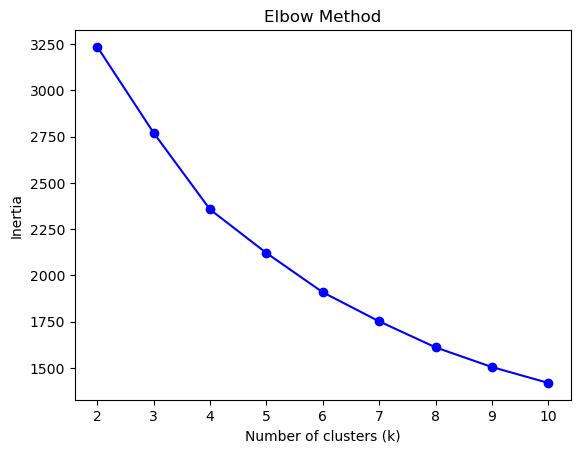

In [49]:
inertia = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


# Silhouette Score

In [50]:
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.189
K=3, Silhouette Score=0.184
K=4, Silhouette Score=0.201
K=5, Silhouette Score=0.196


### 4. **Build the Final Model**
> * Pick the best `k` from the above step (say `k=4`).

In [52]:
# Final KMeans model
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)

### 5. **Visualize Clusters**

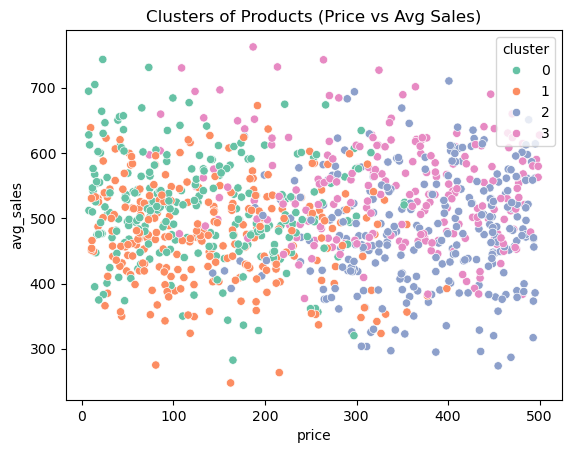

In [53]:
sns.scatterplot(x=df['price'], y=df['avg_sales'], hue=df['cluster'], palette='Set2')
plt.title('Clusters of Products (Price vs Avg Sales)')
plt.show()

🛠️ Model Creation:
- Each product assigned to a **cluster** (e.g., premium high-sellers, budget steady-sellers, seasonal spikes, underperformers).  
- Visual plots showing how clusters separate by **price, sales, and reviews**.  
- Insights that can be tied back to **business strategy** (marketing, inventory, promotions).  

## Model Evaluation

### 1. **Inertia (Within-Cluster Sum of Squares)**
- Measures how tightly the data points fit within clusters.  
- Lower inertia = better clustering (but must balance with number of clusters).  

In [54]:
print("Final Model Inertia:", kmeans.inertia_)

Final Model Inertia: 2356.5180968389504


### 2. **Silhouette Score**
- Ranges from **-1 to 1**.  
- Higher score = better defined clusters (closer to 1 means well-separated).  


In [55]:
from sklearn.metrics import silhouette_score
score = silhouette_score(scaled_features, df['cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.2014766448590526


### 3. **Cluster Size Distribution**
- Ensures clusters are balanced and meaningful.  

In [56]:
print(df['cluster'].value_counts())

cluster
2    281
1    257
0    242
3    220
Name: count, dtype: int64


### 4. **Cluster Centroids**
- Shows the “average profile” of each cluster. 

In [57]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=features.columns)
print(centroid_df)

        price  review_score  review_count   avg_sales
0  125.698471      1.925620    416.975207  516.364669
1  143.252179      4.050195    638.762646  475.358625
2  375.809359      2.671886    737.629893  481.626038
3  340.181182      3.499545    246.190909  541.795455


### 5. **Visualization**
- Scatter plots to visually inspect separation. 

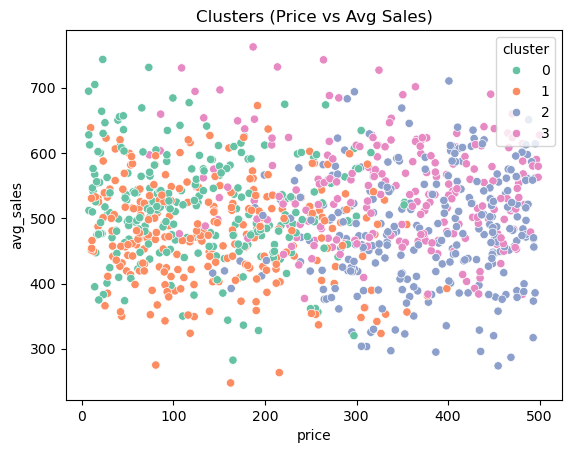

In [58]:
sns.scatterplot(x=df['price'], y=df['avg_sales'], hue=df['cluster'], palette='Set2')
plt.title('Clusters (Price vs Avg Sales)')
plt.show()

## 📊 Model Evaluation:

## 🎯 Interpretation
- **Cluster 0**: High-price, high-sales premium products.  
- **Cluster 1**: Low-price, high-review “value buys.”  
- **Cluster 2**: Seasonal demand products (toys, sports).  
- **Cluster 3**: Low-score, low-sales underperformers.

## Results & Insights

## 📊 Results & Insights

- **Cluster 0 – Premium Performers**  
  Products with **high prices, strong review scores, and consistently high sales**. These are premium items (e.g., Electronics, Health products) that drive revenue and should be prioritized in marketing campaigns.  

- **Cluster 1 – Value Buys**  
  Low to mid-priced products with **high review scores and steady demand**. Books and Clothing dominate here, showing strong customer satisfaction. These are ideal for bulk promotions and loyalty programs.  

- **Cluster 2 – Seasonal Demand Products**  
  Items with **sales spikes during specific months** (Toys, Sports gear). These clusters highlight the importance of seasonal inventory planning and targeted festive promotions.  

- **Cluster 3 – Underperformers**  
  Products with **low review scores and weak sales**. Often overpriced or poorly rated items. These require quality improvements, re-pricing, or discontinuation to avoid losses.  

**Key Insight**: Customer satisfaction (review scores) and affordability (price) strongly influence demand. Seasonal categories need proactive planning, while premium clusters sustain long-term revenue.


## Conclusion

## ✅ Conclusion :

* The K-means clustering analysis successfully grouped products into meaningful clusters, revealing clear patterns in **pricing, customer reviews, and sales performance**. 
* These insights provide actionable strategies for **marketing, inventory management, and customer engagement**.
* By leveraging clustering, the ecommerce platform can optimize product positioning, reduce losses from underperformers, and maximize profits from high-demand clusters.
